# Matrix = some column vectors

![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)  
This work by Jephian Lin is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [ ]:
def make_blobs(N=150, k=3, d=2, seed=None):
    """
    Input:
        N: an integer, number of samples
        k: an integer, number of blobs
        d: an integer, dimension of the space
    Output:
        a dataset X of shape (N, d)
    """
    np.random.seed(seed)
    X = np.random.randn(N,d)
    blob_size = N // k
    centers = np.random.randn(k, d) * 3
    for i in range(k):
        left = blob_size * i
        right = blob_size * (i+1) if i != k-1 else N
        X[left:right] += centers[i]
    return X

## Main idea

Let $S = \{{\bf u}_1, \ldots, {\bf u}_n\}$ be a collection of vectors.  
A **linear combination** of $S$ is a vector of the form  
$${\bf v} = c_1{\bf u}_1 + \cdots + c_n{\bf u}_n$$
where $c_1,\ldots,c_n$ are real numbers.  
The **span** of $S$, denoted by $\operatorname{span}(S)$, is the set of all linear combinations of $S$.

Let  
$$A = \begin{bmatrix}
 | & ~ & | \\
 {\bf u}_1 & \cdots & {\bf u}_n \\
 | & ~ & | \\
\end{bmatrix}$$
be an $m\times n$ matrix.  Let
$${\bf v} = \begin{bmatrix} c_1 \\ \vdots \\ c_n \end{bmatrix}$$
a vector in $\mathbb{R}^n$.  

Then  
$$A{\bf v} = c_1{\bf u}_1 + \cdots + c_n{\bf u}_n$$  
and  
$$\{A{\bf v}: {\bf v}\in\mathbb{R}^n\} = \operatorname{span}(\{{\bf u}_1, \ldots, {\bf u}_n\}),$$
which is called the **column space** $\operatorname{Col}(A)$ of $A$.

## Side stories

- space, column space
- `np.meshgrid`
- center of mass
- shift the data
- NumPy broadcasting

## Experiments

##### Exercise 1
Let
```python
A = np.array([[1,-1],
              [1,1]])
grid = np.meshgrid(np.arange(5), np.arange(5))
xs = grid[0].ravel()
ys = grid[1].ravel()
```

In [ ]:
A = np.array([[1,-1],
              [1, 1]])
grid = np.meshgrid(np.arange(5), np.arange(5))
xs = grid[0].ravel()
ys = grid[1].ravel()

plt.figure(figsize=(12, 5))

# 1(a) 畫出原始網格點 (藍色)
plt.subplot(1, 2, 1)
plt.axis('equal')
plt.title("1(a) Original Grid")
plt.scatter(xs, ys, color='blue', alpha=0.5)

# 1(b) 畫出被 A 轉換後的點 (橘色)
vs = np.vstack([xs, ys]) # 將 xs, ys 疊加成 2 列的矩陣
new_vs = A.dot(vs)

plt.subplot(1, 2, 2)
plt.axis('equal')
plt.title("1(b) & 1(c) Transformed & Columns")
plt.scatter(new_vs[0], new_vs[1], color='orange', alpha=0.5)

# 1(c) 畫出矩陣 A 的兩個行向量 (紅色與綠色箭頭)
plt.quiver(0, 0, A[0,0], A[1,0], angles='xy', scale_units='xy', scale=1, color='red', label='Col 1')
plt.quiver(0, 0, A[0,1], A[1,1], angles='xy', scale_units='xy', scale=1, color='green', label='Col 2')
plt.legend()

plt.show()

###### 1(a)
Plot the points ${\bf v}$ where the x,y-coordinates are stored in `xs` and `ys`, respectively.

In [ ]:

plt.subplot(1, 2, 1)
plt.axis('equal')
plt.title("1(a) Original Grid")
plt.scatter(xs, ys, color='blue', alpha=0.5)

plt.show()

###### 1(b)
Plot the points $A{\bf v}$ where the x,y-coordinates are stored in `xs` and `ys`, respectively.  
Hint:  You might need the function `np.vstack` .

In [ ]:
vs = np.vstack([xs, ys]) # 將 xs, ys 疊加成 2 列的矩陣
new_vs = A.dot(vs)

plt.subplot(1, 2, 2)
plt.axis('equal')
plt.title("1(b) & 1(c) Transformed & Columns")
plt.scatter(new_vs[0], new_vs[1], color='orange', alpha=0.5)



plt.show()

###### 1(c)
Draw the column vectors of $A$ on the figure that you drew earlier.

In [ ]:
plt.quiver(0, 0, A[0,0], A[1,0], angles='xy', scale_units='xy', scale=1, color='red', label='Col 1')
plt.quiver(0, 0, A[0,1], A[1,1], angles='xy', scale_units='xy', scale=1, color='green', label='Col 2')
plt.legend()

plt.show()


##### Exercise 2
Let
```python
A = np.array([[1,1,1],
              [-1,0,0],
              [0,-1,0]])
B = np.array([[1,1,0],
              [-1,0,1],
              [0,-1,-1]])
grid = np.meshgrid(np.arange(5), np.arange(5), np.arange(5))
xs = grid[0].ravel()
ys = grid[1].ravel()
zs = grid[2].ravel()
```

In [ ]:
A = np.array([[1,1,1],
              [-1,0,0],
              [0,-1,0]])
B = np.array([[1,1,0],
              [-1,0,1],
              [0,-1,-1]])
grid = np.meshgrid(np.arange(5), np.arange(5), np.arange(5))
xs = grid[0].ravel()
ys = grid[1].ravel()
zs = grid[2].ravel()
vs = np.vstack([xs, ys, zs])

fig = plt.figure(figsize=(15, 5))

# 2(a)
new_vs_A = A.dot(vs)
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_xlim(-5,5); ax1.set_ylim(-5,5); ax1.set_zlim(-5,5)
ax1.set_title("2(a) Grid by A")
ax1.scatter(new_vs_A[0], new_vs_A[1], new_vs_A[2], s=5)

# 2(b)
new_vs_B = B.dot(vs)
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_xlim(-5,5); ax2.set_ylim(-5,5); ax2.set_zlim(-5,5)
ax2.set_title("2(b) Grid by B")
ax2.scatter(new_vs_B[0], new_vs_B[1], new_vs_B[2], s=5)


# 2(c)
grid_2d = np.meshgrid(np.arange(5), np.arange(5))
vs_2d = np.vstack([grid_2d[0].ravel(), grid_2d[1].ravel()])
A_sub = A[:, :2] # 取前兩個 column
new_vs_A_sub = A_sub.dot(vs_2d)

ax3 = fig.add_subplot(133, projection='3d')
ax3.set_xlim(-5,5); ax3.set_ylim(-5,5); ax3.set_zlim(-5,5)
ax3.set_title("2(c) Span(u1,u2) and u3")
ax3.scatter(new_vs_A_sub[0], new_vs_A_sub[1], new_vs_A_sub[2], color='orange', s=10)

u3 = A[:, 2] # 第三個 column
ax3.quiver(0, 0, 0, u3[0], u3[1], u3[2], color='red', length=2, normalize=True)

# u3 不在 span({u1, u2}) 中。從圖中可看出，紅色箭頭(u3)指出了橘色平面以外的方向。

plt.show()

###### 2(a)
Draw the grid using the columns of $A$ on the three dimensional space.  
Remeber you need the following to setup a 3d-axes.  
```python
%matplotlib notebook
ax = plt.axes(projection='3d')
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(-5,5)
```

In [ ]:
# 2(a)
new_vs_A = A.dot(vs)
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_xlim(-5,5); ax1.set_ylim(-5,5); ax1.set_zlim(-5,5)
ax1.set_title("2(a) Grid by A")
ax1.scatter(new_vs_A[0], new_vs_A[1], new_vs_A[2], s=5)


plt.show()

###### 2(b)
Draw the grid using the columns of $B$ on the three dimensional space.  
What's the main difference between (a) and (b)?

In [ ]:
# 2(b)
new_vs_B = B.dot(vs)
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_xlim(-5,5); ax2.set_ylim(-5,5); ax2.set_zlim(-5,5)
ax2.set_title("2(b) Grid by B")
ax2.scatter(new_vs_B[0], new_vs_B[1], new_vs_B[2], s=5)

plt.show()

###### 2(c)
Let ${\bf u}_1, {\bf u}_2, {\bf u}_3$ be the column vectors of $A$.  
Draw the grid using $S = \{{\bf u}_1, {\bf u}_2\}$ and draw an arrow for ${\bf u}_3$.  
Is ${\bf u}_3$ in $\operatorname{span}(S)$?  
Hint:  You might need `np.quiver`.

In [ ]:
# 2(c)
grid_2d = np.meshgrid(np.arange(5), np.arange(5))
vs_2d = np.vstack([grid_2d[0].ravel(), grid_2d[1].ravel()])
A_sub = A[:, :2] # 取前兩個 column
new_vs_A_sub = A_sub.dot(vs_2d)

ax3 = fig.add_subplot(133, projection='3d')
ax3.set_xlim(-5,5); ax3.set_ylim(-5,5); ax3.set_zlim(-5,5)
ax3.set_title("2(c) Span(u1,u2) and u3")
ax3.scatter(new_vs_A_sub[0], new_vs_A_sub[1], new_vs_A_sub[2], color='orange', s=10)

u3 = A[:, 2] # 第三個 column
ax3.quiver(0, 0, 0, u3[0], u3[1], u3[2], color='red', length=2, normalize=True)

# u3 不在 span({u1, u2}) 中。從圖中可看出，紅色箭頭(u3)指出了橘色平面以外的方向。

plt.show()

## Exercises

##### Exercise 3
Let  
```python
x = np.array([0,1,2])
y = np.array([3,4,5])
```

In [ ]:
x = np.array([0,1,2])
y = np.array([3,4,5])

# 3(a)
print("3(a) x - y:\n", x - y)
# 維度相同 (3,)，直接對應位置相減。

# 3(b)
print("\n3(b) x[:,np.newaxis] - y:\n", x[:,np.newaxis] - y)
# (3,1) 減 (3,)。Numpy 會將兩者都擴充成 (3,3) 的矩陣再相減。等同於 x 的每個元素分別去減掉 y 陣列的每個元素。

# 3(c)
print("\n3(c) x[:,np.newaxis] - y[np.newaxis,:]:\n", x[:,np.newaxis] - y[np.newaxis,:])
# (3,1) 減 (1,3)。結果和 3(b) 一模一樣，這是標準的廣播產生外積(Outer difference)的寫法。

# 3(d)
ys = np.arange(15).reshape(3,5)
print("\n3(d) x[:,np.newaxis] - ys:\n", x[:,np.newaxis] - ys)
# (3,1) 減 (3,5)。x[:,np.newaxis] 會在橫向複製 5 次變成 (3,5)，然後再與 ys 相減。

###### 3(a)
Guess and understand the meaning of `x - y` .

In [ ]:
# 3(a)
print("3(a) x - y:\n", x - y)
# 維度相同 (3,)，直接對應位置相減。

###### 3(b)
Guess and understand the meaning of `x[:,np.newaxis] - y` .

In [ ]:
# 3(b)
print("\n3(b) x[:,np.newaxis] - y:\n", x[:,np.newaxis] - y)
# (3,1) 減 (3,)。Numpy 會將兩者都擴充成 (3,3) 的矩陣再相減。等同於 x 的每個元素分別去減掉 y 陣列的每個元素。

###### 3(c)
Guess and understand the meaning of `x[:,np.newaxis] - y[np.newaxis,:]` .

In [ ]:
# 3(c)
print("\n3(c) x[:,np.newaxis] - y[np.newaxis,:]:\n", x[:,np.newaxis] - y[np.newaxis,:])
# (3,1) 減 (1,3)。結果和 3(b) 一模一樣，這是標準的廣播產生外積(Outer difference)的寫法。

###### 3(d)
Let  
```python
ys = np.arange(15).reshape(3,5)
```
Guess and understand the meaning of `x[:,np.newaxis] - ys` .

In [ ]:
# 3(d)
ys = np.arange(15).reshape(3,5)
print("\n3(d) x[:,np.newaxis] - ys:\n", x[:,np.newaxis] - ys)
# (3,1) 減 (3,5)。x[:,np.newaxis] 會在橫向複製 5 次變成 (3,5)，然後再與 ys 相減。

##### Exercise 4
Let  
```python
A = np.array([[1,1],
              [-1,0],
              [0,-1]])
p = np.array([1,1,1])
grid = np.meshgrid(np.arange(5), np.arange(5))
xs = grid[0].ravel()
ys = grid[1].ravel()

vs = np.vstack([xs,ys])
new_vs = A.dot(vs)
```

In [ ]:
A = np.array([[1,1],
              [-1,0],
              [0,-1]])
p = np.array([1,1,1])
grid = np.meshgrid(np.arange(5), np.arange(5))
xs = grid[0].ravel()
ys = grid[1].ravel()

vs = np.vstack([xs,ys])
new_vs = A.dot(vs)

fig = plt.figure(figsize=(12, 5))

# 4(a) 畫出原點與向量 p
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("4(a) Origin and vector p")
ax1.scatter(0, 0, 0, color='red', s=50, label='Origin')
ax1.quiver(0, 0, 0, p[0], p[1], p[2], color='green', label='p')
ax1.legend()

# 4(b) 畫出平移後的點
shifted_vs = p[:,np.newaxis] + new_vs
#將原本由 A 展開的平面空間，整體沿著向量 p 平移，這在幾何上稱為「仿射平面 (Affine plane)」。

ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("4(b) Shifted plane")
ax2.scatter(0, 0, 0, color='red', s=50, label='Origin')
ax2.quiver(0, 0, 0, p[0], p[1], p[2], color='green', label='p')
ax2.scatter(shifted_vs[0], shifted_vs[1], shifted_vs[2], s=5, color='purple', alpha=0.5)

plt.show()

###### 4(a)
Draw a red point at the origin and an arrow for `p` .

In [ ]:
# 4(a) 畫出原點與向量 p
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("4(a) Origin and vector p")
ax1.scatter(0, 0, 0, color='red', s=50, label='Origin')
ax1.quiver(0, 0, 0, p[0], p[1], p[2], color='green', label='p')
ax1.legend()

plt.show()

###### 4(b)
Let `shifted_vs = p[:,np.newaxis] + new_vs` .  
What is the meaning of `shifted_vs` ?  
Draw the points (columns) in `shifted_vs` along with a red point at the oirign and an arrow for `p` .  

In [ ]:
# 4(b) 畫出平移後的點
shifted_vs = p[:,np.newaxis] + new_vs
#將原本由 A 展開的平面空間，整體沿著向量 p 平移，這在幾何上稱為「仿射平面 (Affine plane)」。

ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("4(b) Shifted plane")
ax2.scatter(0, 0, 0, color='red', s=50, label='Origin')
ax2.quiver(0, 0, 0, p[0], p[1], p[2], color='green', label='p')
ax2.scatter(shifted_vs[0], shifted_vs[1], shifted_vs[2], s=5, color='purple', alpha=0.5)

plt.show()

##### Exercise 5
Let  
```python
A = np.array([[1,1],
              [-1,0],
              [0,-1]])
p = np.array([1,0,0])
grid = np.meshgrid(np.linspace(-10,10,100), np.linspace(-10,10,100))
xs = grid[0].ravel()
ys = grid[1].ravel()

vs = np.vstack([xs,ys])
new_vs = A.dot(vs)
```

In [ ]:
A = np.array([[1,1],
              [-1,0],
              [0,-1]])
p = np.array([1,0,0])
grid = np.meshgrid(np.linspace(-10,10,100), np.linspace(-10,10,100))
xs = grid[0].ravel()
ys = grid[1].ravel()

vs = np.vstack([xs,ys])
new_vs = A.dot(vs)

# 5(a) 計算差異與距離
diff = p[:,np.newaxis] - new_vs
dist = np.sqrt(np.sum(diff**2, axis=0))
# diff 計算了點 p 到平面上每個網格點的向量差；dist 則是計算這些向量的歐幾里得長度(L2 norm)，也就是 p 到平面上每個網格點的「直線距離」。

# 5(b) 尋找最短距離與最近點 (投影點)
min_dist = np.min(dist)
closest_idx = np.argmin(dist)
closest_point = new_vs[:, closest_idx]

print("最短距離 (min dist):", min_dist)
print("投影點 (closest point):", closest_point)

###### 5(a)
Calculate
```python
diff = p[:,np.newaxis] - new_vs
dist = np.sqrt(np.sum(diff**2, axis=0))
```
and guess the meaning of dist.

In [ ]:
# 5(a) 計算差異與距離
diff = p[:,np.newaxis] - new_vs
dist = np.sqrt(np.sum(diff**2, axis=0))

###### 5(b)
Use `np.min` to find the shortest distance beteen `p` and a point in `new_vs` .  
Use `np.argmin` to find this point in `new_vs` .  
(This point is the projection of `p` onto the column space of `A` .)

In [ ]:
# 5(b) 尋找最短距離與最近點 (投影點)
min_dist = np.min(dist)
closest_idx = np.argmin(dist)
closest_point = new_vs[:, closest_idx]

##### Exercise 6
Let `X = make_blobs(k=1)` .  

In [ ]:
X = make_blobs(k=1)

plt.figure(figsize=(10, 4))

# 6(a) 畫出原始資料與原點
plt.subplot(1, 2, 1)
plt.axis('equal')
plt.title("6(a) Original Data")
plt.scatter(X[:,0], X[:,1], alpha=0.6)
plt.scatter(0, 0, color='red', s=100, marker='x', label='Origin')
plt.legend()

# 6(b) 尋找質心
mu = X.mean(axis=0)

# 6(c) 資料平移
new_X = X - mu
# new_X 代表「中心化」後的資料，將整群點平移，使得它們的質心剛好落在原點 (0,0)。

plt.subplot(1, 2, 2)
plt.axis('equal')
plt.title("6(c) Centered Data (new_X)")
plt.scatter(new_X[:,0], new_X[:,1], color='orange', alpha=0.6)
plt.scatter(0, 0, color='red', s=100, marker='x', label='Origin')
plt.legend()

plt.show()

###### 6(a)
Draw a red point at the origin and the points (rows) in `X` .

In [ ]:
# 6(a) 畫出原始資料與原點
plt.subplot(1, 2, 1)
plt.axis('equal')
plt.title("6(a) Original Data")
plt.scatter(X[:,0], X[:,1], alpha=0.6)
plt.scatter(0, 0, color='red', s=100, marker='x', label='Origin')
plt.legend()

plt.show()

###### 6(b)
Suppose $\{{\bf x}_i\}_{i=1}^n$ are some points.  
Then the **center of mass** is at $\frac{1}{n}\sum_{i=1}^n {\bf x}_i$.  
Let $\{{\bf x}_i\}_i$ be the rows of `X` .  
Use `mu = X.mean( ... )` to find the center of mass.

In [ ]:
# 6(b) 尋找質心
mu = X.mean(axis=0)

plt.show()

###### 6(c)
Let `new_X = X - mu`.  
(Guess its meaning.)  
Draw a red point at the origin and the points (rows) in `new_X` .

In [ ]:
# 6(c) 資料平移
new_X = X - mu
# new_X 代表「中心化」後的資料，將整群點平移，使得它們的質心剛好落在原點 (0,0)。

plt.subplot(1, 2, 2)
plt.axis('equal')
plt.title("6(c) Centered Data (new_X)")
plt.scatter(new_X[:,0], new_X[:,1], color='orange', alpha=0.6)
plt.scatter(0, 0, color='red', s=100, marker='x', label='Origin')
plt.legend()

plt.show()

##### Exercise 7
For the following equality, pick some random matrices or vectors and check if the equality is true.

In [ ]:
# 7(a) 驗證 tr(A^T A) = sum(a_ij^2)
A = np.random.randn(5, 5)
tr_AtA = np.trace(A.T @ A)
sum_sq = np.sum(A**2)
print("7(a) 是否相等:", np.isclose(tr_AtA, sum_sq))

# 7(b) 驗證 (AB)^T = B^T A^T
A_mb = np.random.randn(3, 4)
B_mb = np.random.randn(4, 2)
LHS = (A_mb @ B_mb).T
RHS = B_mb.T @ A_mb.T
print("7(b) 是否相等:", np.allclose(LHS, RHS))

# 7(c) 驗證 <Ax, y> = y^T A x = <x, A^T y>
A_c = np.random.randn(3, 4)
x_c = np.random.randn(4)
y_c = np.random.randn(3)

val1 = np.dot(A_c.dot(x_c), y_c)        # <Ax, y>
val2 = y_c.T.dot(A_c.dot(x_c))          # y^T A x
val3 = np.dot(x_c, A_c.T.dot(y_c))      # <x, A^T y>

print("7(c) 是否相等:", np.isclose(val1, val2) and np.isclose(val2, val3))

###### 7(a)
The **trace** of an $n\times n$ matrix $A=\begin{bmatrix}a_{ij}\end{bmatrix}$ is  
$$\operatorname{tr}(A) = a_{11} + a_{22} + \cdots + a_{nn}.$$  
For any $n\times n$ matrix $A=\begin{bmatrix}a_{ij}\end{bmatrix}$,  
$$\operatorname{tr}(A^\top A) = \sum_{i=1}^n\sum_{j=1}^n a_{ij}^2.$$

In [ ]:
# 7(a) 驗證 tr(A^T A) = sum(a_ij^2)
A = np.random.randn(5, 5)
tr_AtA = np.trace(A.T @ A)
sum_sq = np.sum(A**2)
print("7(a) 是否相等:", np.isclose(tr_AtA, sum_sq))

###### 7(b)
Let $A$ be an $m\times n$ matrix and $B$ an $n\times \ell$ matrix.  
Then $(AB)^\top = B^\top A^\top$.  

In [ ]:
# 7(b) 驗證 (AB)^T = B^T A^T
A_mb = np.random.randn(3, 4)
B_mb = np.random.randn(4, 2)
LHS = (A_mb @ B_mb).T
RHS = B_mb.T @ A_mb.T
print("7(b) 是否相等:", np.allclose(LHS, RHS))

###### 7(c)
Let $A$ be an $m\times n$ matrix, ${\bf x}\in\mathbb{R}^n$, ${\bf y}\in\mathbb{R}^m$.  
Then $\langle A{\bf x}, {\bf y}\rangle = {\bf y}^\top A{\bf x} = \langle {\bf x}, A^\top{\bf y}\rangle$.  

In [ ]:
# 7(c) 驗證 <Ax, y> = y^T A x = <x, A^T y>
A_c = np.random.randn(3, 4)
x_c = np.random.randn(4)
y_c = np.random.randn(3)

val1 = np.dot(A_c.dot(x_c), y_c)        # <Ax, y>
val2 = y_c.T.dot(A_c.dot(x_c))          # y^T A x
val3 = np.dot(x_c, A_c.T.dot(y_c))      # <x, A^T y>

print("7(c) 是否相等:", np.isclose(val1, val2) and np.isclose(val2, val3))

**answer**

========== Exercise 1: 2D 矩陣變換與行空間 ==========


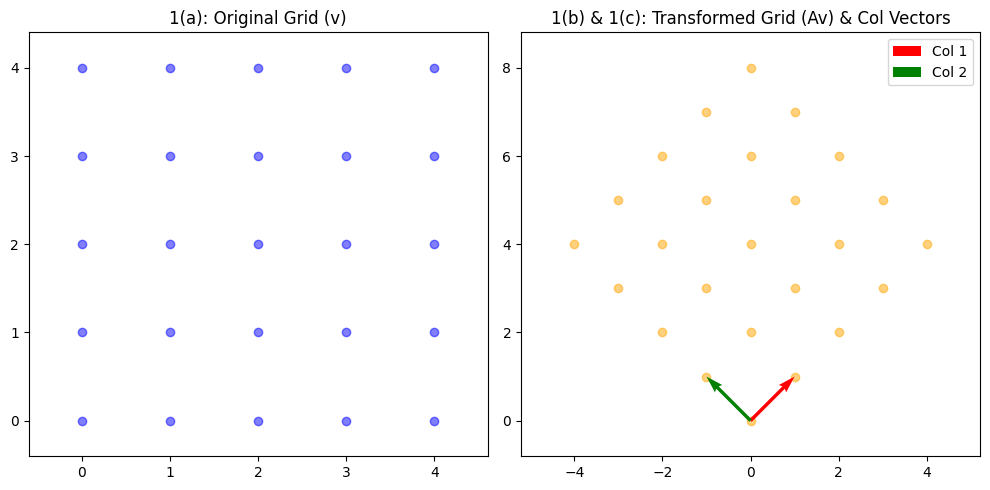


========== Exercise 2: 3D 矩陣變換 ==========


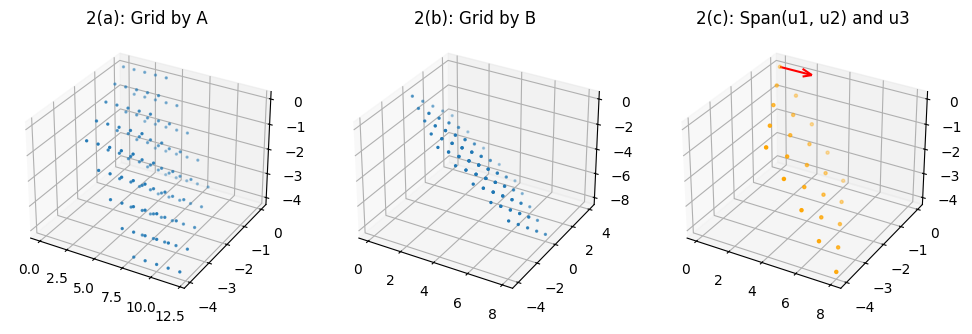


========== Exercise 3: Broadcasting (廣播) ==========
3(a) x - y :
 [-3 -3 -3]

3(b) x[:,np.newaxis] - y :
 [[-3 -4 -5]
 [-2 -3 -4]
 [-1 -2 -3]]

3(c) x[:,np.newaxis] - y[np.newaxis,:] :
 [[-3 -4 -5]
 [-2 -3 -4]
 [-1 -2 -3]]

3(d) x[:,np.newaxis] - ys :
 [[  0  -1  -2  -3  -4]
 [ -4  -5  -6  -7  -8]
 [ -8  -9 -10 -11 -12]]

========== Exercise 4: 空間平移 ==========


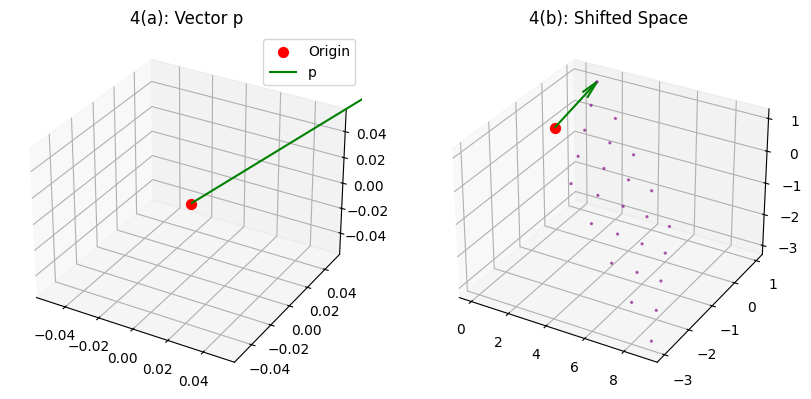


========== Exercise 5: 最短距離與投影 ==========
5(b) p 點到平面的最短距離: 0.5821022034029864
5(b) 最接近 p 的平面上的點 (投影點): [ 0.60606061 -0.3030303  -0.3030303 ]

========== Exercise 6: 質心與資料中心化 ==========


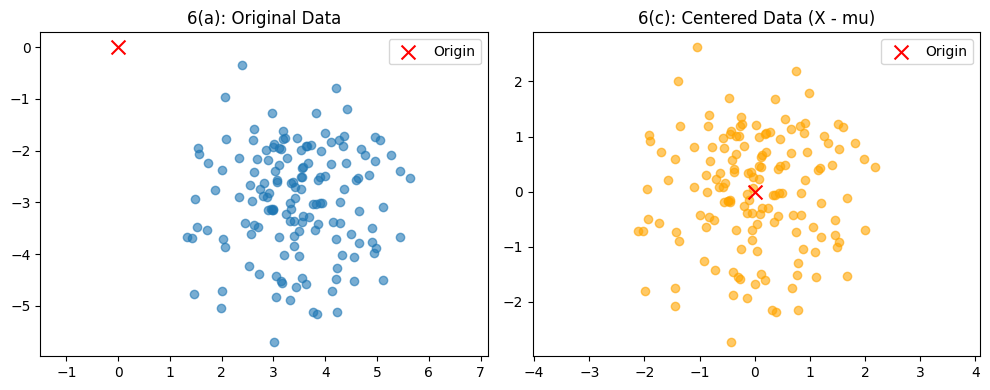


========== Exercise 7: 驗證矩陣特性 ==========
7(a) 兩邊是否相等: True
7(b) 兩邊是否相等: True
7(c) 三個表示法是否皆相等: True


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


def make_blobs(N=150, k=3, d=2, seed=None):
    """生成隨機群聚資料點"""
    np.random.seed(seed)
    X = np.random.randn(N,d)
    blob_size = N // k
    centers = np.random.randn(k, d) * 3
    for i in range(k):
        left = blob_size * i
        right = blob_size * (i+1) if i != k-1 else N
        X[left:right] += centers[i]
    return X


print("========== Exercise 1: 2D 矩陣變換與行空間 ==========")
A1 = np.array([[1,-1],
               [1, 1]])
grid1 = np.meshgrid(np.arange(5), np.arange(5))
xs1 = grid1[0].ravel()
ys1 = grid1[1].ravel()

plt.figure(figsize=(10, 5))

# 1(a) 畫出原始的網格點
plt.subplot(1, 2, 1)
plt.axis('equal')
plt.title("1(a): Original Grid (v)")
plt.scatter(xs1, ys1, color='blue', alpha=0.5)

# 1(b) 畫出被 A 轉換後的點 A*v
vs1 = np.vstack([xs1, ys1])  # 將 x,y 堆疊成 2 x 25 的矩陣
new_vs1 = A1.dot(vs1)        # 矩陣乘法

plt.subplot(1, 2, 2)
plt.axis('equal')
plt.title("1(b) & 1(c): Transformed Grid (Av) & Col Vectors")
plt.scatter(new_vs1[0], new_vs1[1], color='orange', alpha=0.5)

# 1(c) 畫出 A 的行向量 (Column vectors)
# A 的第一行 [1, 1]^T 和第二行 [-1, 1]^T
plt.quiver(0, 0, A1[0,0], A1[1,0], angles='xy', scale_units='xy', scale=1, color='red', label='Col 1')
plt.quiver(0, 0, A1[0,1], A1[1,1], angles='xy', scale_units='xy', scale=1, color='green', label='Col 2')
plt.legend()
plt.tight_layout()
plt.show()


print("\n========== Exercise 2: 3D 矩陣變換 ==========")
A2 = np.array([[1,1,1],
               [-1,0,0],
               [0,-1,0]])
B2 = np.array([[1,1,0],
               [-1,0,1],
               [0,-1,-1]])
grid2 = np.meshgrid(np.arange(5), np.arange(5), np.arange(5))
xs2 = grid2[0].ravel()
ys2 = grid2[1].ravel()
zs2 = grid2[2].ravel()
vs2 = np.vstack([xs2, ys2, zs2])

# 2(a) A 變換後的網格
new_vs_A = A2.dot(vs2)
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title("2(a): Grid by A")
ax1.scatter(new_vs_A[0], new_vs_A[1], new_vs_A[2], s=2)

# 2(b) B 變換後的網格
new_vs_B = B2.dot(vs2)
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title("2(b): Grid by B")
ax2.scatter(new_vs_B[0], new_vs_B[1], new_vs_B[2], s=2)
# A 轉換後依然是一個立體的 3D 空間 (Rank=3)，但 B 轉換後的點全部落在一個 2D 平面上 (Rank=2，因為 B 的行向量存在線性相依)。

# 2(c) 使用 A 的前兩個 column 畫網格，並畫出第三個 column 向量
grid2c = np.meshgrid(np.arange(5), np.arange(5))
vs2c = np.vstack([grid2c[0].ravel(), grid2c[1].ravel()])
A_sub = A2[:, :2] # 取前兩行
new_vs_A_sub = A_sub.dot(vs2c)

ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title("2(c): Span(u1, u2) and u3")
ax3.scatter(new_vs_A_sub[0], new_vs_A_sub[1], new_vs_A_sub[2], s=5, color='orange')
u3 = A2[:, 2]
ax3.quiver(0, 0, 0, u3[0], u3[1], u3[2], color='red', length=2, normalize=True)
plt.show()
# u3 不在 span({u1, u2}) 裡面，因為紅色的箭頭(u3)明顯指出了橘色平面以外的方向。


print("\n========== Exercise 3: Broadcasting (廣播) ==========")
x = np.array([0,1,2])
y = np.array([3,4,5])

print("3(a) x - y :\n", x - y)
# 解釋: 形狀相同 (3,)，做 Element-wise 相減。

print("\n3(b) x[:,np.newaxis] - y :\n", x[:,np.newaxis] - y)
# 解釋: (3, 1) 減 (3,)，廣播機制會把它們都擴充成 (3, 3) 的矩陣再相減。這相當於把 x 的每個元素分別減去 y 的整個陣列。

print("\n3(c) x[:,np.newaxis] - y[np.newaxis,:] :\n", x[:,np.newaxis] - y[np.newaxis,:])
# 解釋: (3, 1) 減 (1, 3)，結果與 3(b) 完全相同。

ys = np.arange(15).reshape(3,5)
print("\n3(d) x[:,np.newaxis] - ys :\n", x[:,np.newaxis] - ys)
# 解釋: (3, 1) 減 (3, 5)，廣播機制會把 (3, 1) 在 column 方向複製 5 次變成 (3, 5)，然後做對應位置的相減。


print("\n========== Exercise 4: 空間平移 ==========")
A4 = np.array([[1,1],
               [-1,0],
               [0,-1]])
p4 = np.array([1,1,1])
grid4 = np.meshgrid(np.arange(5), np.arange(5))
vs4 = np.vstack([grid4[0].ravel(), grid4[1].ravel()])
new_vs4 = A4.dot(vs4)

fig = plt.figure(figsize=(10, 5))

# 4(a)
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("4(a): Vector p")
ax1.scatter(0, 0, 0, color='red', s=50, label='Origin')
ax1.quiver(0, 0, 0, p4[0], p4[1], p4[2], color='green', label='p')
ax1.legend()

# 4(b)
shifted_vs = p4[:, np.newaxis] + new_vs4
# shifted_vs 的意義是將原本的行空間 (由 A 展成的平面) 沿著向量 p 平移 (Translation)。這個動作產生了一個「仿射空間 (Affine Space)」。
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("4(b): Shifted Space")
ax2.scatter(0, 0, 0, color='red', s=50)
ax2.quiver(0, 0, 0, p4[0], p4[1], p4[2], color='green')
ax2.scatter(shifted_vs[0], shifted_vs[1], shifted_vs[2], s=2, color='purple', alpha=0.5)
plt.show()


print("\n========== Exercise 5: 最短距離與投影 ==========")


#[Image of vector projection]

A5 = np.array([[1,1],
               [-1,0],
               [0,-1]])
p5 = np.array([1,0,0])
grid5 = np.meshgrid(np.linspace(-10,10,100), np.linspace(-10,10,100))
vs5 = np.vstack([grid5[0].ravel(), grid5[1].ravel()])
new_vs5 = A5.dot(vs5)

# 5(a)
diff = p5[:, np.newaxis] - new_vs5
dist = np.sqrt(np.sum(diff**2, axis=0))
#  diff 算出了點 p 到平面上「每一個網格點」的差距向量。 dist 則是計算這些向量的歐幾里得長度 (L2-norm)。所以 dist 代表 p 點到平面上各個點的直線距離。

# 5(b)
min_dist = np.min(dist)
closest_idx = np.argmin(dist)
closest_point = new_vs5[:, closest_idx]

print("5(b) p 點到平面的最短距離:", min_dist)
print("5(b) 最接近 p 的平面上的點 (投影點):", closest_point)


print("\n========== Exercise 6: 質心與資料中心化 ==========")
X = make_blobs(k=1)

plt.figure(figsize=(10, 4))

# 6(a)
plt.subplot(1, 2, 1)
plt.axis('equal')
plt.title("6(a): Original Data")
plt.scatter(X[:,0], X[:,1], alpha=0.6)
plt.scatter(0, 0, color='red', s=100, marker='x', label='Origin')
plt.legend()

# 6(b) 求質心
mu = X.mean(axis=0)

# 6(c) 資料中心化
new_X = X - mu
# new_X 代表「中心化 (Mean Centering)」過後的資料。也就是把所有資料點平移，讓這群點的質心剛好落在原點 (0,0) 上。這在機器學習 (如 PCA) 中是非常關鍵的前置處理步驟。
plt.subplot(1, 2, 2)
plt.axis('equal')
plt.title("6(c): Centered Data (X - mu)")
plt.scatter(new_X[:,0], new_X[:,1], color='orange', alpha=0.6)
plt.scatter(0, 0, color='red', s=100, marker='x', label='Origin')
plt.legend()
plt.tight_layout()
plt.show()


print("\n========== Exercise 7: 驗證矩陣特性 ==========")

# 7(a) tr(A^T A) = sum(a_ij^2)
A7 = np.random.randn(3, 3)
tr_AtA = np.trace(A7.T @ A7)
sum_sq = np.sum(A7**2)
print("7(a) 兩邊是否相等:", np.isclose(tr_AtA, sum_sq))

# 7(b) (AB)^T = B^T A^T
A_mb = np.random.randn(3, 4)
B_mb = np.random.randn(4, 2)
LHS_b = (A_mb @ B_mb).T
RHS_b = B_mb.T @ A_mb.T
print("7(b) 兩邊是否相等:", np.allclose(LHS_b, RHS_b))

# 7(c) <Ax, y> = <x, A^T y>
A_c = np.random.randn(3, 4)
x_c = np.random.randn(4)
y_c = np.random.randn(3)

val1 = np.dot(A_c @ x_c, y_c)        # <Ax, y>
val2 = y_c.T @ (A_c @ x_c)           # y^T (Ax)
val3 = np.dot(x_c, A_c.T @ y_c)      # <x, A^T y>

print("7(c) 三個表示法是否皆相等:", np.isclose(val1, val2) and np.isclose(val2, val3))